
=== ELITE CAPTURE THRESHOLD REGRESSION: OECD (ADVANCED) ===
Searching 1000 thresholds between 24.9% and 104.5% Debt-to-GDP...


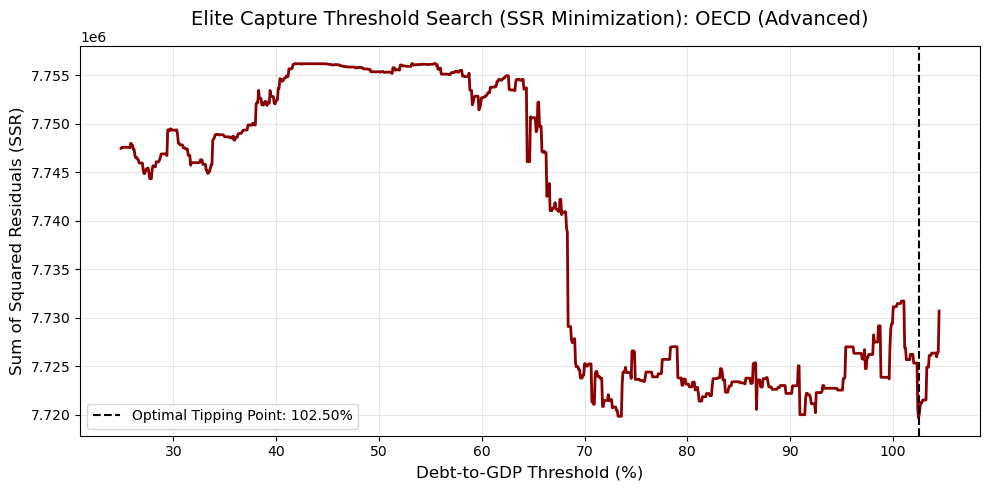


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 102.50% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -9.4138     14.320    -0.6574     0.5111     -37.523      18.695
Debt_Below_Gamma                       0.2167     0.2111     1.0266     0.3049     -0.1976      0.6310
Debt_Above_Gamma                      -0.1039     0.1777    -0.5845     0.5590     -0.4527      0.2449
GDP growth (annual %)                  1.0153     0.6524     1.5564     0.1200     -0.2652      2.2958
Gross capital formation (% of GDP)     0.6587     0.6776     0.9721     0.3313     -0.6714      1.9888
Inflation (Annual %)                   0.3109     0.4287     0.7253     0.4685     -0.5305      1.1524


=

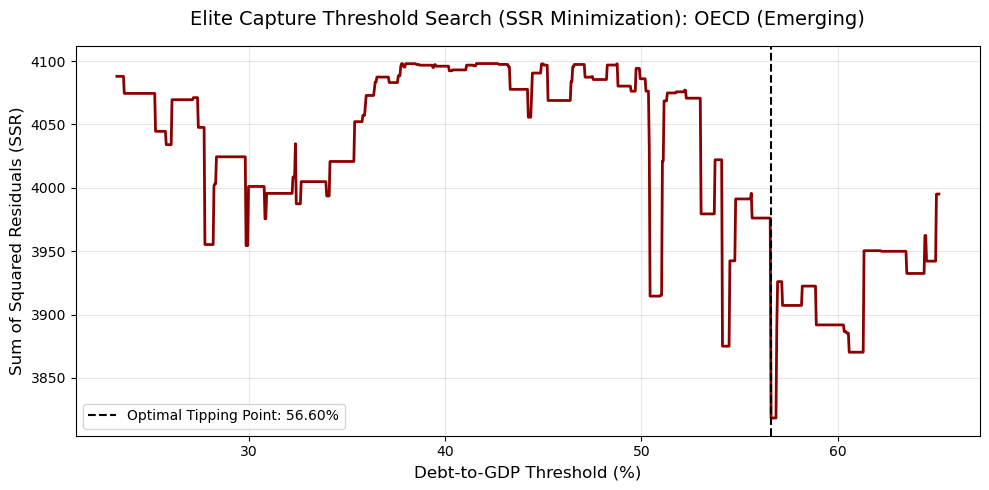


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 56.60% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                 -10.074     9.0407    -1.1143     0.2676     -27.990      7.8429
Debt_Below_Gamma                       0.0301     0.0764     0.3941     0.6943     -0.1214      0.1816
Debt_Above_Gamma                       0.1440     0.0719     2.0025     0.0477      0.0015      0.2864
GDP growth (annual %)                 -0.4272     0.2934    -1.4562     0.1482     -1.0086      0.1542
Gross capital formation (% of GDP)     0.7492     0.2979     2.5151     0.0133      0.1589      1.3395
Inflation (Annual %)                   0.0145     0.0538     0.2688     0.7886     -0.0922      0.1212


==

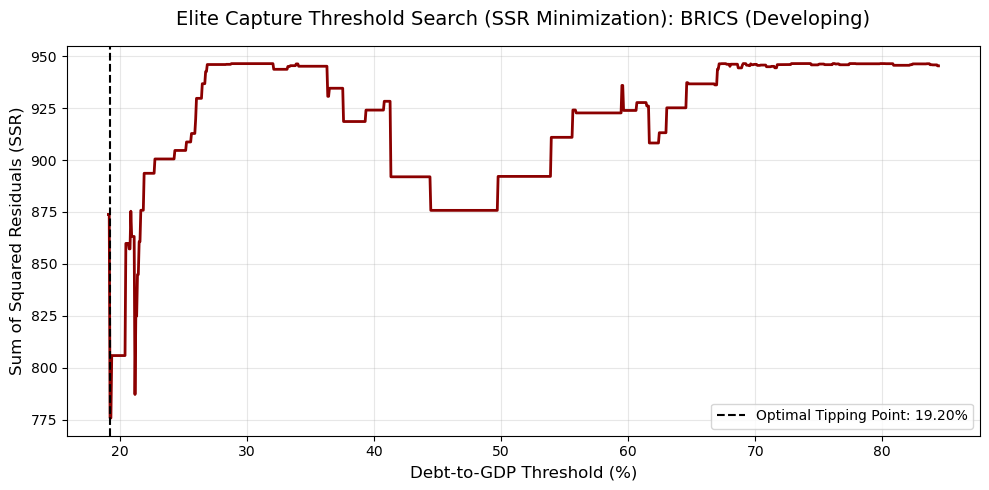


>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: 19.20% DEBT-TO-GDP <<

                                         Parameter Estimates                                          
                                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------------------
const                                  4.2561     2.7681     1.5376     0.1271     -1.2307      9.7429
Debt_Below_Gamma                       0.3756     0.1306     2.8760     0.0049      0.1167      0.6344
Debt_Above_Gamma                      -0.0110     0.0208    -0.5320     0.5958     -0.0522      0.0301
GDP growth (annual %)                 -0.3320     0.1612    -2.0600     0.0418     -0.6515     -0.0125
Gross capital formation (% of GDP)     0.4850     0.1160     4.1806     0.0001      0.2550      0.7149
Inflation (Annual %)                   0.0156     0.0352     0.4420     0.6594     -0.0542      0.0854



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. LOAD MASTER DATA & CALCULATE WEALTH RATIO
# ==============================================================================
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
master_file = PROCESSED_DIR / "master_panel_data.csv"

df = pd.read_csv(master_file)
df = df.set_index(['Country Name', 'Year'])

BRICS_NATIONS = ["Brazil", "Russia", "India", "China", "Egypt", "United Arab Emirates"]
OECD_EMERGING = ["Chile", "Colombia", "Costa Rica", "Turkey", "Hungary", "Poland"]

def categorize_economy(country):
    if country in BRICS_NATIONS: return 'BRICS (Developing)'
    elif country in OECD_EMERGING: return 'OECD (Emerging)'
    else: return 'OECD (Advanced)'

df['Economic_Bloc'] = [categorize_economy(c) for c, y in df.index]

# Calculate the Elite Capture Ratio
TOP_10_COL = 'Wealth Inequality (Top 10%)'
BOTTOM_50_COL = 'Wealth Inequality (Bottom 50%)'
df['Wealth_Ratio_Top10_to_Bottom50'] = df[TOP_10_COL] / df[BOTTOM_50_COL]
df.replace([np.inf, -np.inf], np.nan, inplace=True)

Y_VAR = 'Wealth_Ratio_Top10_to_Bottom50'
DEBT_VAR = 'General Government Debt (% of GDP)'

# Standard WID controls 
EXOG_VARS = [
    'GDP growth (annual %)',
    'Gross capital formation (% of GDP)',
    'Inflation (Annual %)'
]

# ==============================================================================
# 2. PANEL THRESHOLD GRID SEARCH ALGORITHM (ELITE CAPTURE)
# ==============================================================================
def run_threshold_regression(data, bloc_name):
    print(f"\n{'='*85}")
    print(f"=== ELITE CAPTURE THRESHOLD REGRESSION: {bloc_name.upper()} ===")
    print(f"{'='*85}")
    
    # Extract clean data for the specific bloc
    reg_data = data[[Y_VAR, DEBT_VAR] + EXOG_VARS].dropna()
    
    if len(reg_data) < 30:
        print("Skipping due to insufficient data.")
        return
        
    # Define the search grid (trimming extreme 15% tails to avoid outliers)
    min_debt = reg_data[DEBT_VAR].quantile(0.15)
    max_debt = reg_data[DEBT_VAR].quantile(0.85)
    
    # Create 1,000 possible threshold points between the min and max
    grid = np.linspace(min_debt, max_debt, 1000)
    
    best_ssr = np.inf
    best_gamma = None
    best_res = None
    ssr_history = []
    
    print(f"Searching 1000 thresholds between {min_debt:.1f}% and {max_debt:.1f}% Debt-to-GDP...")
    
    for gamma in grid:
        # Create Threshold Splines
        reg_data['Debt_Below_Gamma'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] <= gamma)
        reg_data['Debt_Above_Gamma'] = reg_data[DEBT_VAR] * (reg_data[DEBT_VAR] > gamma)
        
        Y = reg_data[Y_VAR]
        X = sm.add_constant(reg_data[['Debt_Below_Gamma', 'Debt_Above_Gamma'] + EXOG_VARS])
        
        # Run Fixed Effects (Entity and Time effects included precisely as in 05)
        model = PanelOLS(Y, X, entity_effects=True, time_effects=True)
        res = model.fit(cov_type='robust')
        
        # Calculate Sum of Squared Residuals (SSR) using .resids and .squeeze()
        ssr = float(res.resids.squeeze().dot(res.resids.squeeze()))
        ssr_history.append((gamma, ssr))
        
        # Track the absolute best model
        if ssr < best_ssr:
            best_ssr = ssr
            best_gamma = gamma
            best_res = res

    # --- 3. VISUALIZATION OF THE THRESHOLD SEARCH ---
    gammas, ssrs = zip(*ssr_history)
    
    plt.figure(figsize=(10, 5))
    plt.plot(gammas, ssrs, color='darkred', linewidth=2) # Changed to darkred for inequality styling
    plt.axvline(x=best_gamma, color='black', linestyle='--', label=f'Optimal Tipping Point: {best_gamma:.2f}%')
    plt.title(f'Elite Capture Threshold Search (SSR Minimization): {bloc_name}', fontsize=14, pad=15)
    plt.xlabel('Debt-to-GDP Threshold (%)', fontsize=12)
    plt.ylabel('Sum of Squared Residuals (SSR)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- 4. PRINT BEST MODEL RESULTS ---
    print(f"\n>> OPTIMAL ELITE CAPTURE THRESHOLD FOUND AT: {best_gamma:.2f}% DEBT-TO-GDP <<\n")
    print(best_res.summary.tables[1])
    print("="*85 + "\n")

# ==============================================================================
# 3. EXECUTE FOR CORE BLOCS
# ==============================================================================
if __name__ == "__main__":
    for bloc in ['OECD (Advanced)', 'OECD (Emerging)', 'BRICS (Developing)']:
        df_bloc = df[df['Economic_Bloc'] == bloc]
        run_threshold_regression(df_bloc, bloc)